# Trajectory and velocity analysis of scRNAseq COLON data 

This is one in the series of notebooks presenting the data analysis done in the study "Widespread epithelial dedifferentiation in patients with ulcerative colitis". It is also intended as a tutorial in scRNAseq analysis. Please refer to the REAMDE file for the description of different parts of the tutorial and how to follow it.  

## Part 3. Dimentionality reduction

This is the third part of the guide in which we perform dimentionality reduction of the dataset, first with PCA and then with UMAP. Part of the process is finding cell neighbours which we use as an oportunity to implement another batch correcting method. 

### Healthy dataset

This notebook shows the pipeline done on the "Healthy dataset" (see study for details regarding samples constituting the dataset). Here I am explaining the procedure step by step, so hopefully one can repeat it on their own data. In this repository there are also notebooks showing the same pipeline for other datasets from the study. I am not repeating the descriptions in those, so please always refer to the "Healthy dataset" notebooks while following the tutorial. 

Here I am working on 4 samples which I want to merge together into one condition - Healthy. You need to adjust the code accordingly to the number of samples/conditions you're working on. 

#### 0. Imports and settings

In [1]:
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt

#### 1. Load data

First lets load the file we have prepared in the previous part of the tutorial.

In [2]:
adata = sc.read('Healthy_norm.h5ad')

#### 2. PCA

Similarly to batch correction with MNNs(see Part 2), doing Principle Component Analysis (PCA) on all of the genes is inefficient and unnecessary. That is why we choose to work only on the top variable genes. 

In [3]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False)

Actual PCA is just a one-liner. 

In [4]:
sc.tl.pca(adata, svd_solver='arpack')

Now we are ready to make some plots. PCA is not only neccessary for UMAP visualisations, but also allows us to quickly insepct the dataset on a fundamental level. This should show us the most outstanding patterns in the data, giving us a general overview of what can we expect.

On a more technical note, most 'tool' functions in scanpy `sc.tl` have a corresponding plotting functions `sc.pl` which lets you inspect the results. Plotting output can be adjusted through many parameters, which are explained in more detail in the [official documentation](https://scanpy.readthedocs.io/en/stable/api/). Here, I am giving a few examples of how to present the results. You are of course welcome to experiment with your own designs.

In [5]:
scv.settings.set_figure_params('scvelo', dpi=75, vector_friendly=True, figsize=[6,6])

First, let's visualisce some of the quality statistics.

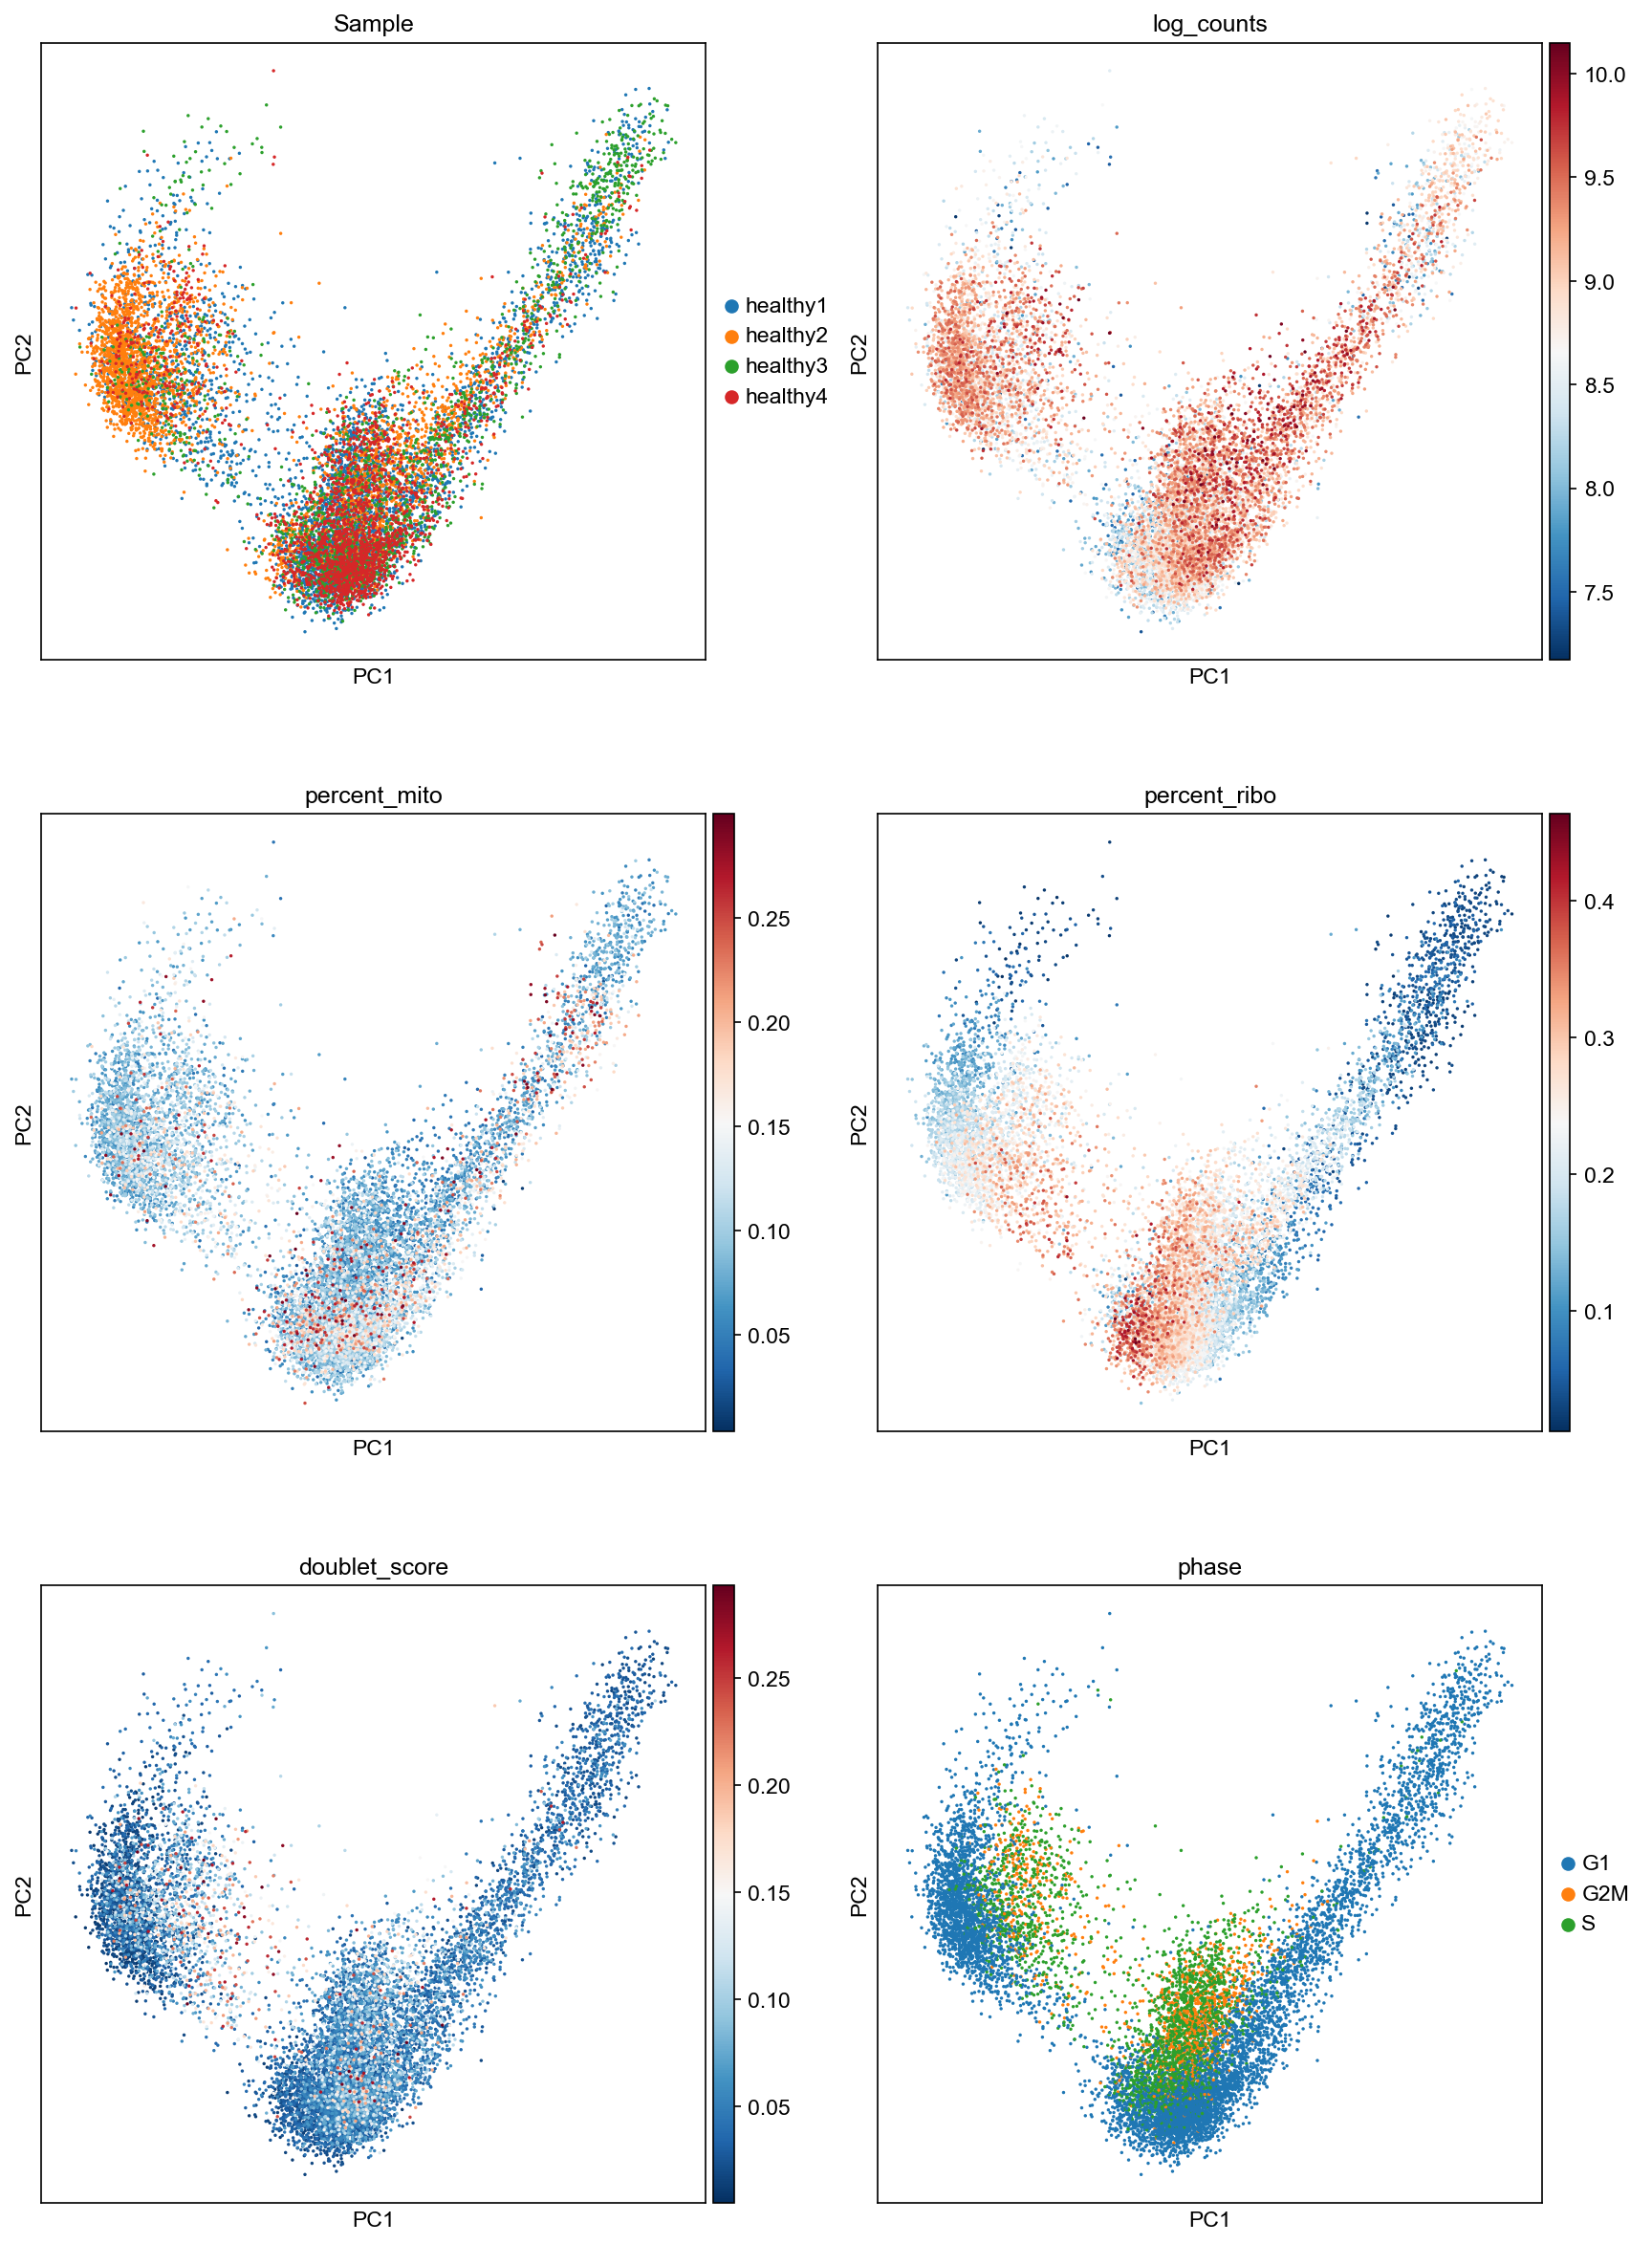

In [6]:
features = ['Sample', 'log_counts', 'percent_mito', 'percent_ribo', 'doublet_score', 'phase']
sc.pl.pca(adata, color=features, ncols=2)

As we can see in the first PCA plot, the dataset does not seem to separate by the sample, which means the batch correction worked. Also the other quality metrics does not reveil any obvious biases caused by poor quality cells. Cycling cells still cluster together, despite previous attempts on minimizing the effect of cell cycle. This may be due to he fact that those cells represent a separate cell population with a fully unique transcriptional profile, not only when it comes to cell cycles related genes.

The advantage of working with a PC representation is that we get multiple components where each should represent another dimention of variability in our data. This lets us inspect the components one by one to see which gene signature is responsible for discrimnating the dataset into known biological divisions (e.g. cell types, lineages, lines). In the plotting functions you can change which PCs to look at with the `components` parameter.

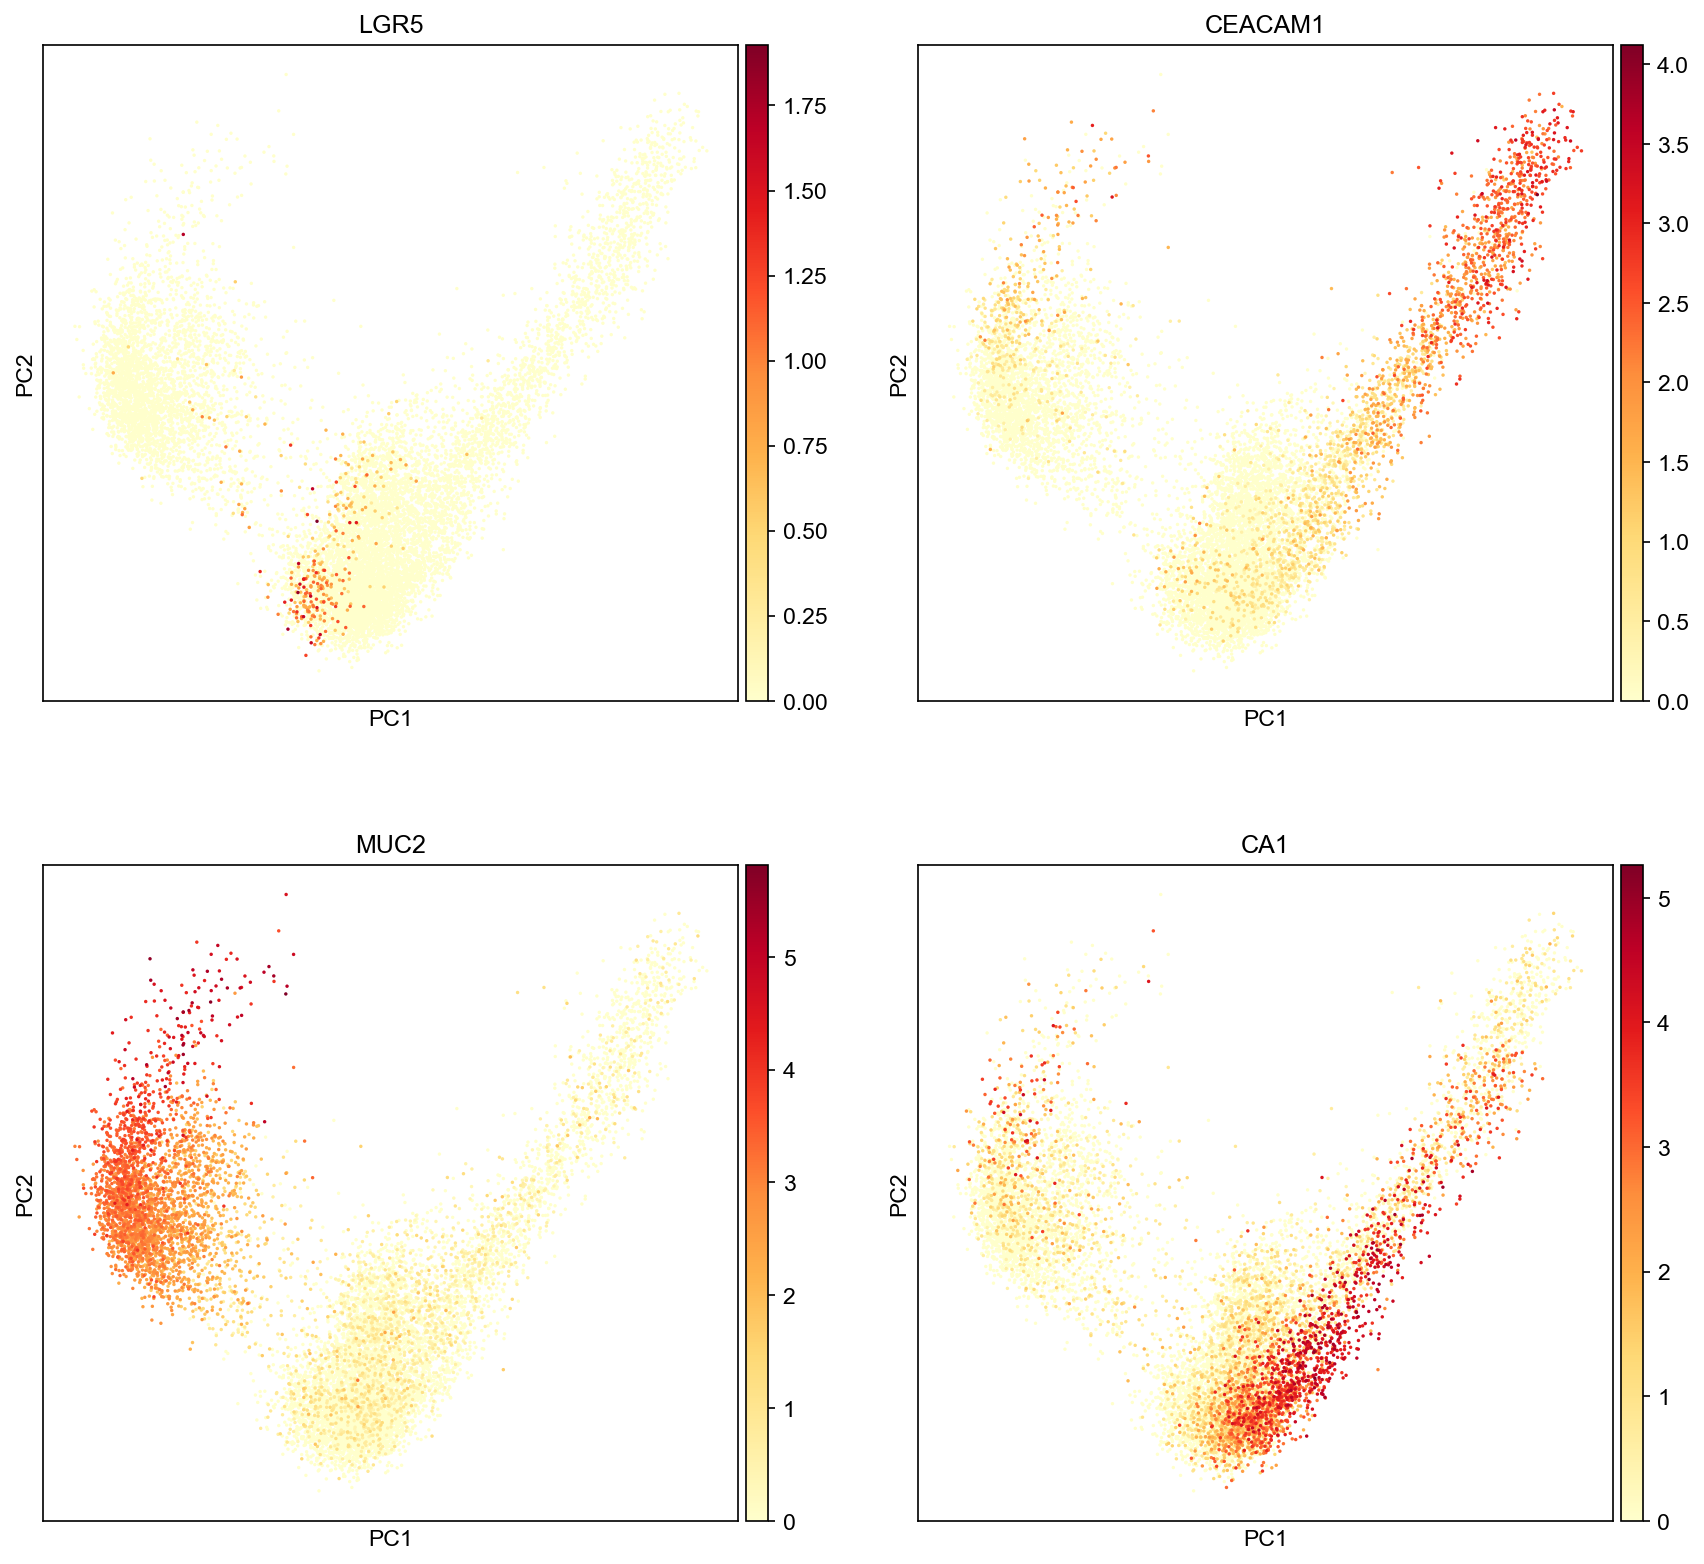

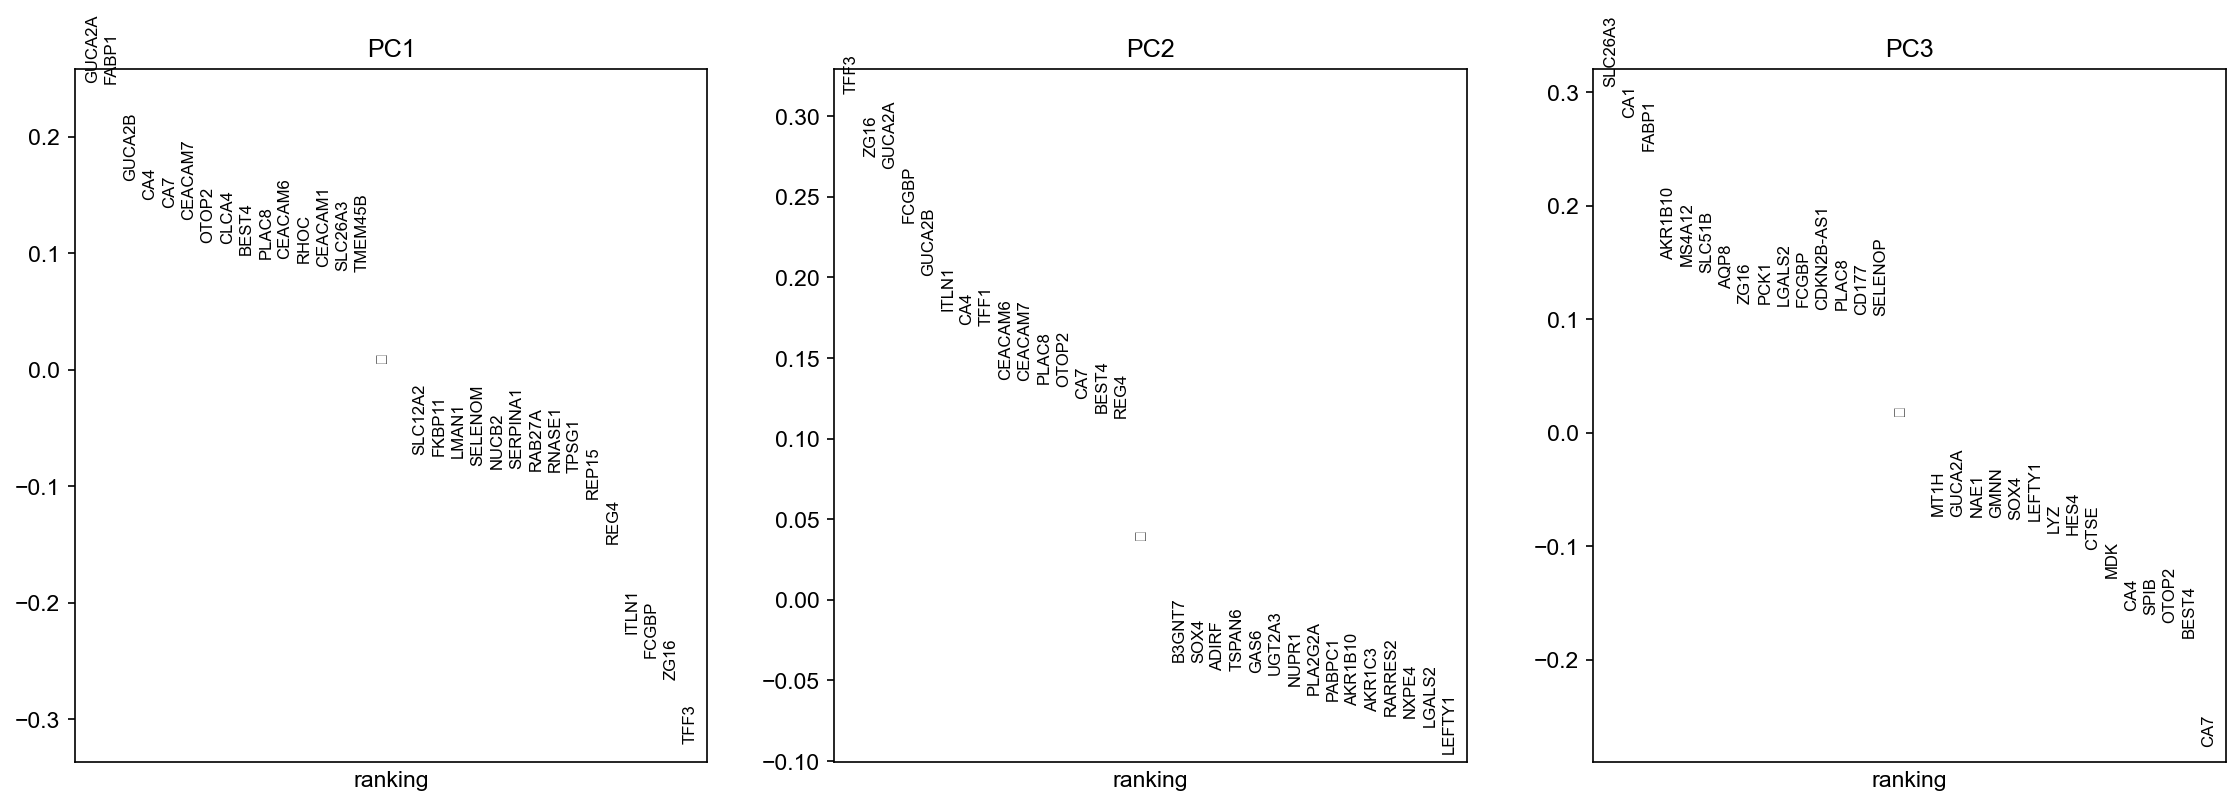

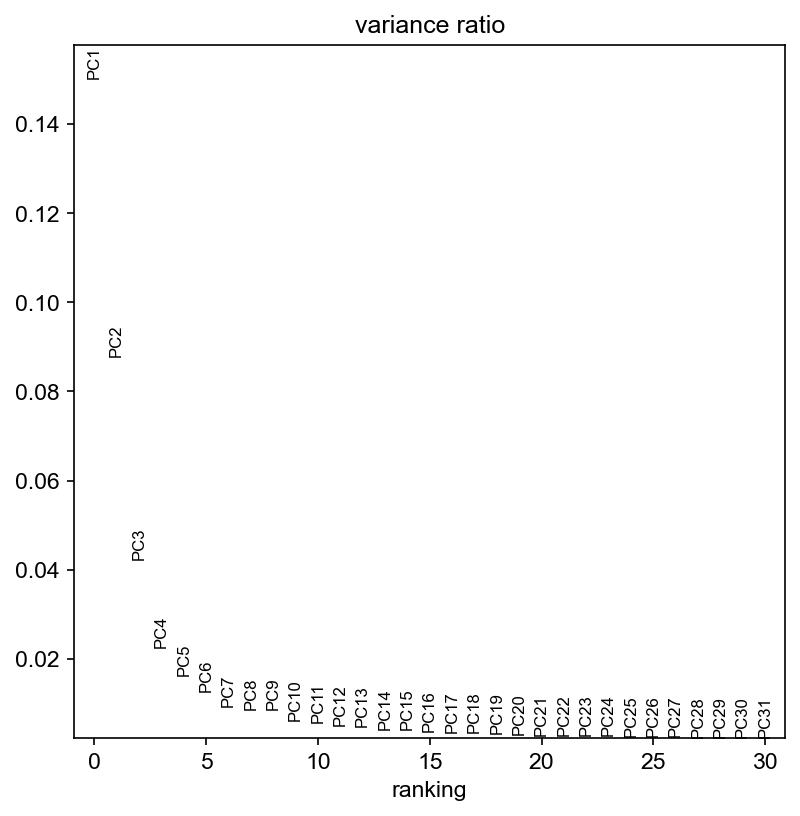

In [7]:
features = ['LGR5', 'CEACAM1', 'MUC2', 'CA1']
sc.pl.pca_overview(adata, color=features, ncols=2, components=['1,2'], cmap='YlOrRd')

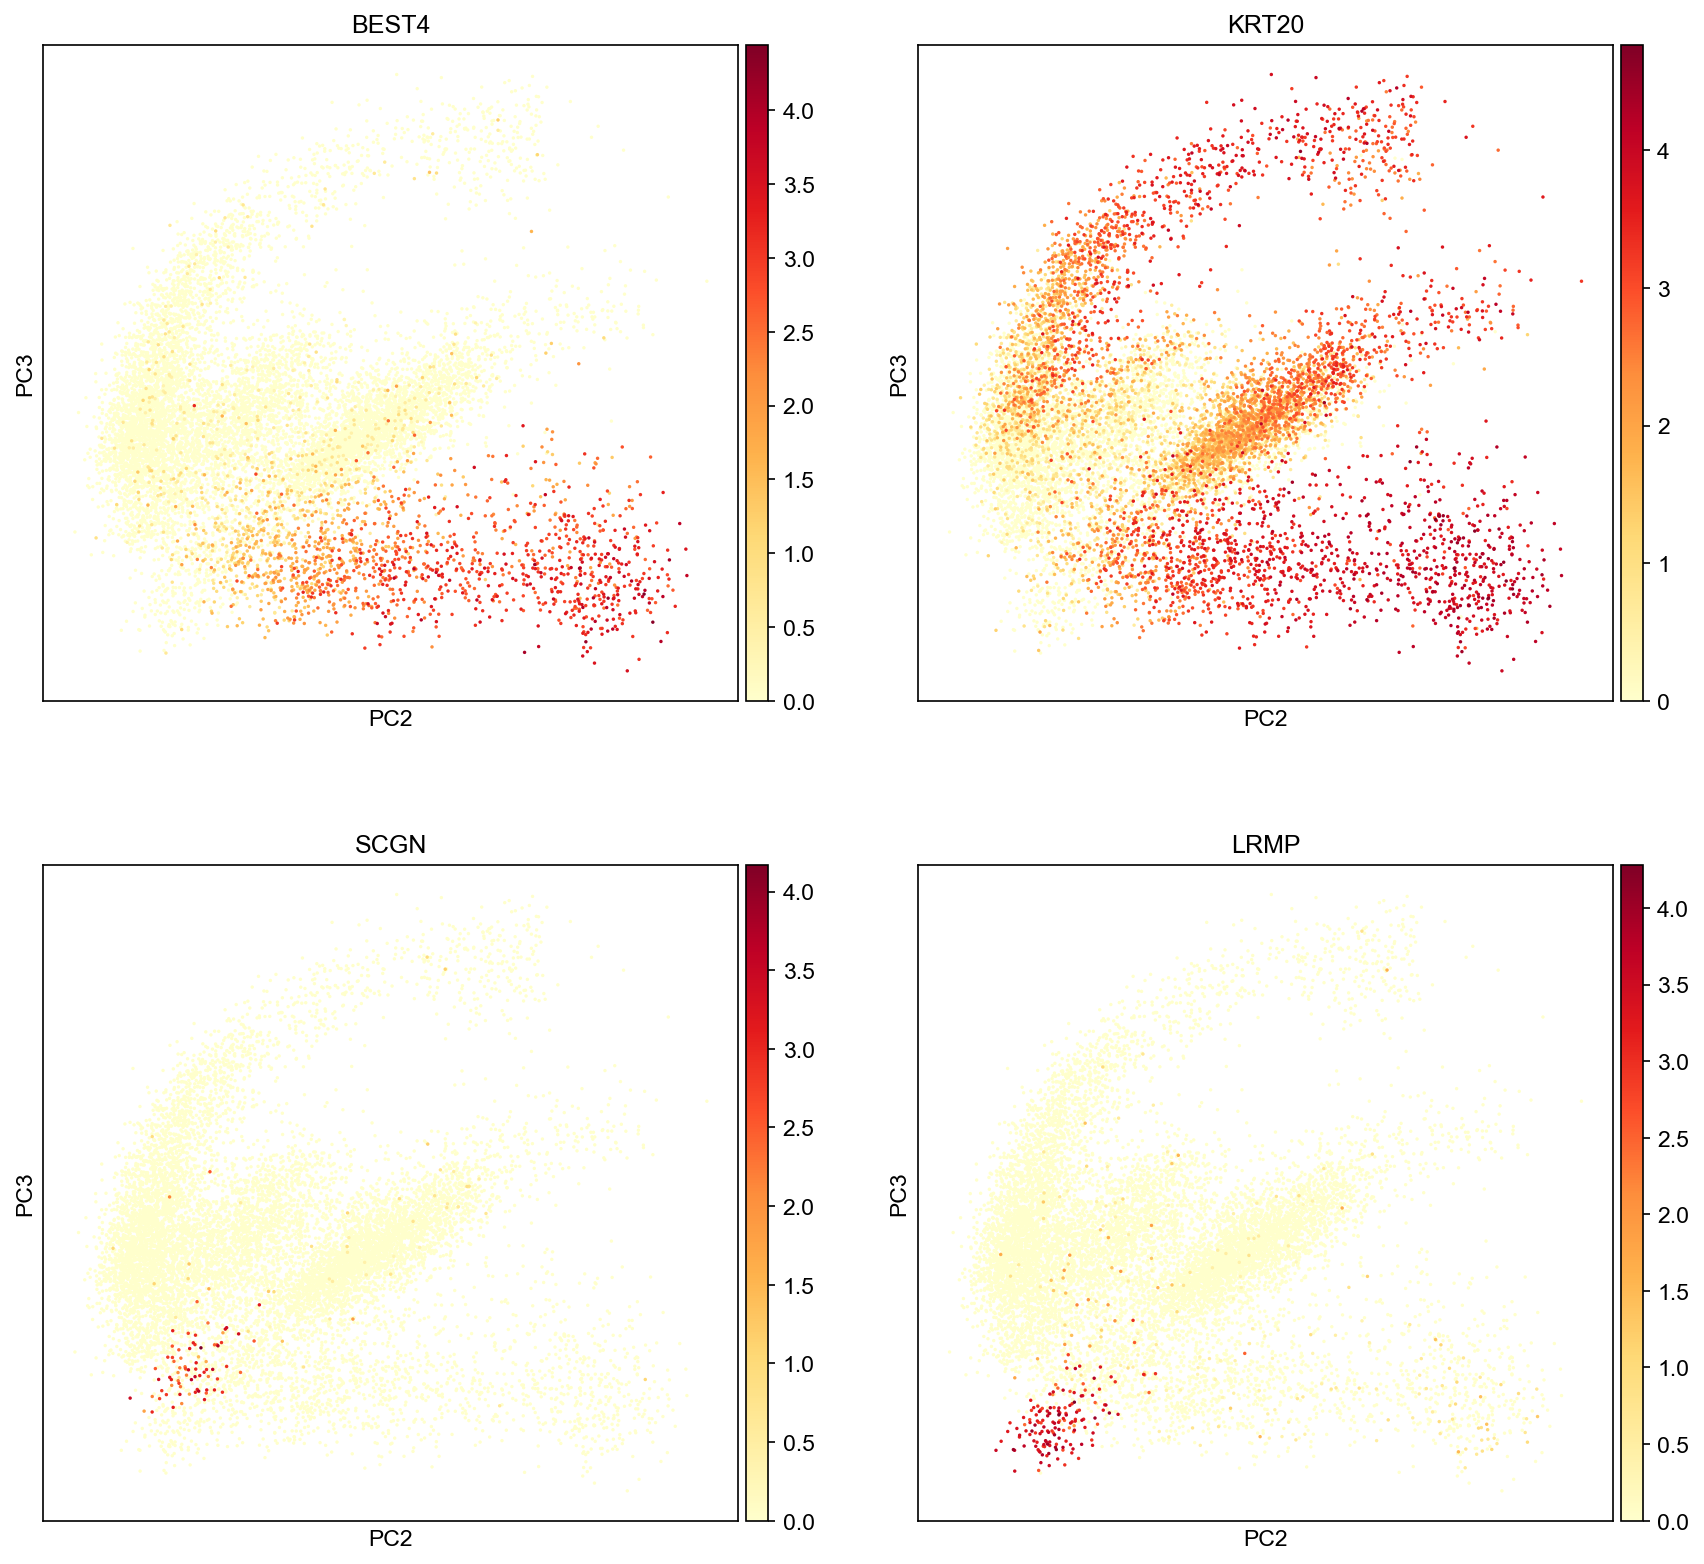

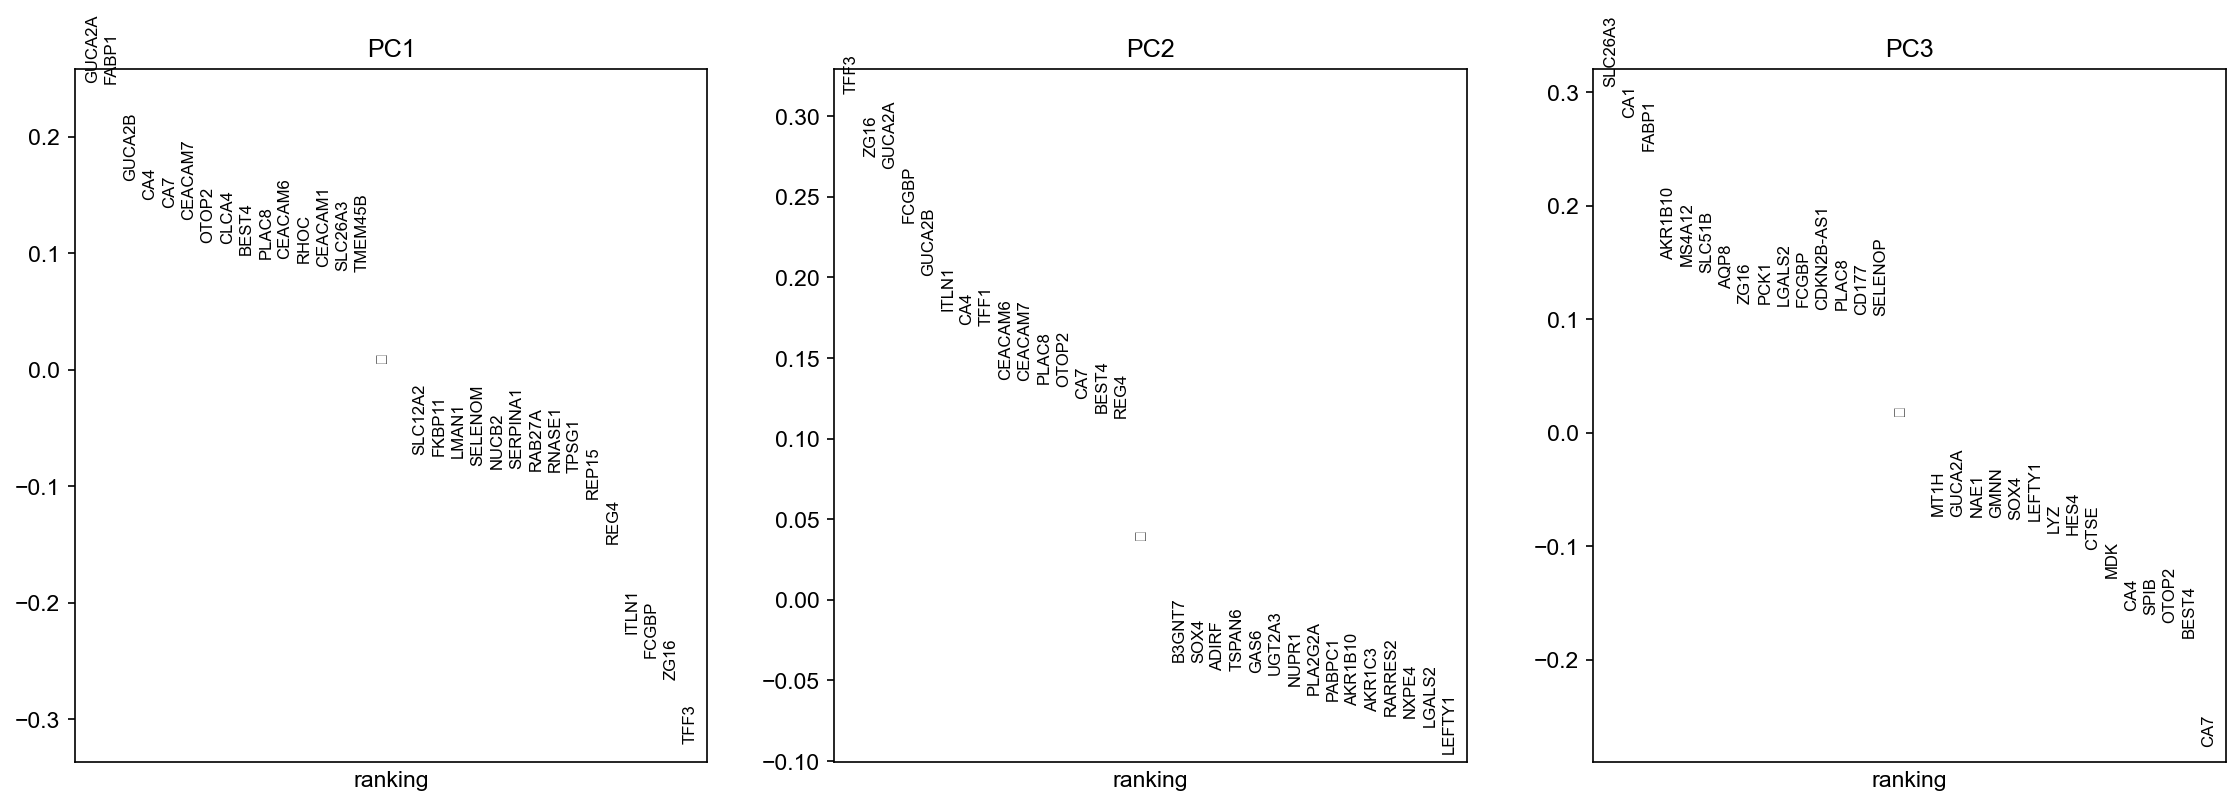

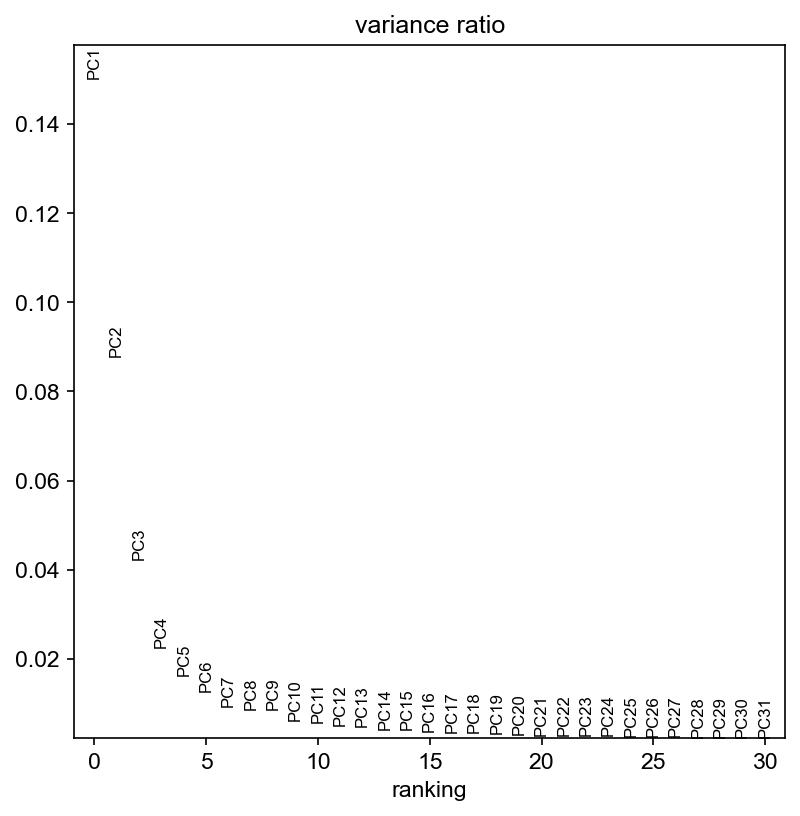

In [8]:
features = ['BEST4', 'KRT20', 'SCGN', 'LRMP']
sc.pl.pca_overview(adata, color=features, ncols=2, components=['2,3'], cmap='YlOrRd')

Visualise some of the marker genes we see how their expression patterns match the structure of the PCA representation.

We can see above that majority of the variance in the dataset is biological and comes from differences between cell lineages:
- Crypt top vs bottom (PC1)
- Goblet lineage vs colonocyte lineage (PC2)
- BEST4 colonocytes vs colonocyte lineage (PC3)

In the case of this dataset the underlying biology (division into cell lineages) is clearly visible even with a surface level examination. This does not always has to be the case, but is a good sanity check before more involved analysis.

We can also present the gene expression in a bit different way.

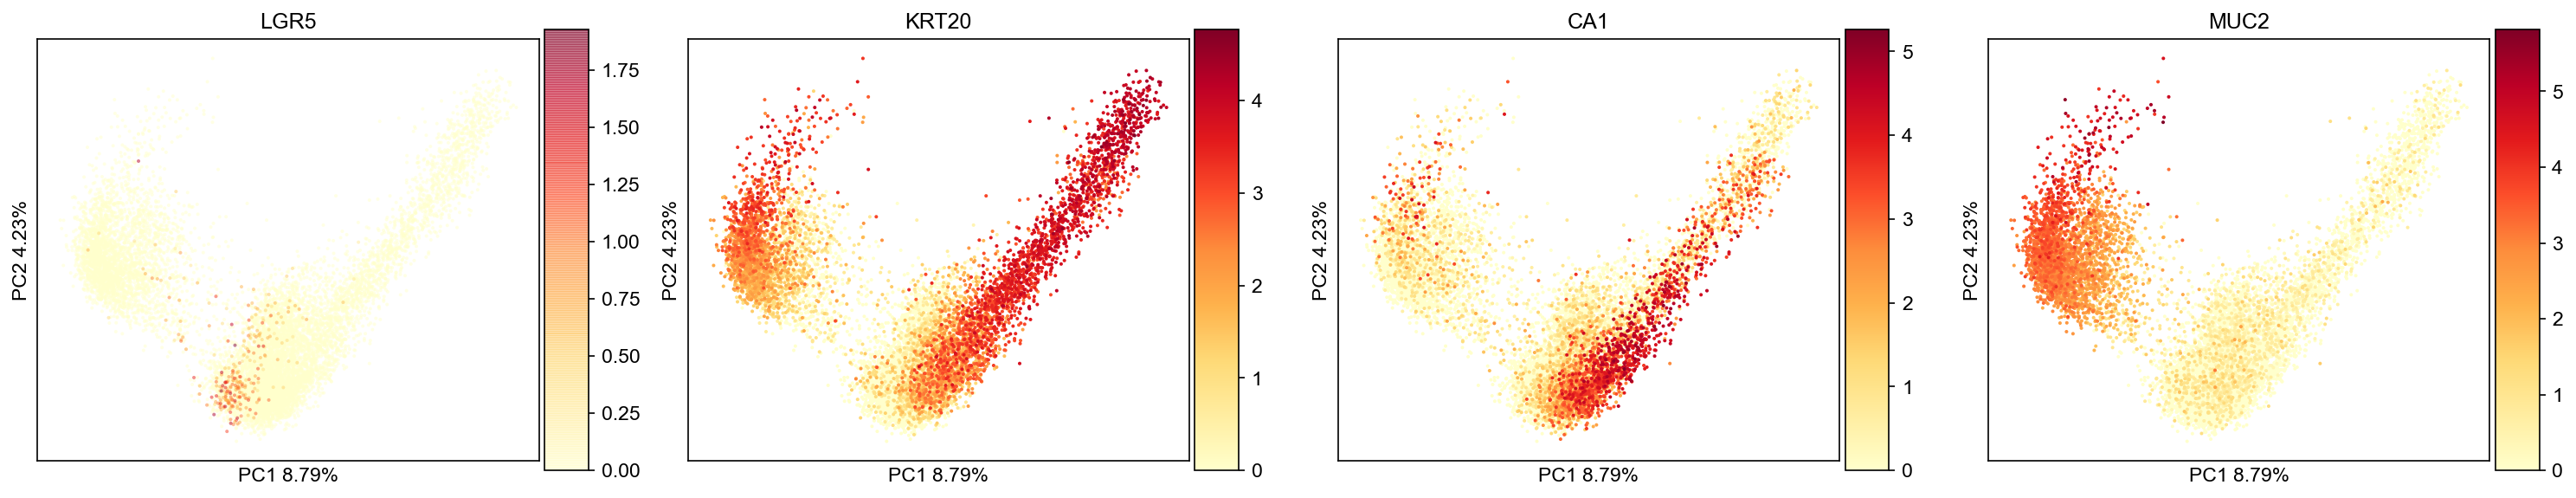

In [9]:
# This long code lets you plot multiple genes in one figure with axis labels showing the amount of variance explained by a PC.
# You can of course show other variables, not only genes.
# PCX, PCY should be integers corresponding to PCs you want to plot on X and Y axis

def labelled_PCA_plot(PCX, PCY, gene1, gene2, gene3, gene4):

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,10))

    sc.pl.pca(adata, color=gene1, cmap='YlOrRd', alpha=0.5, ax=ax1, show=False, size=15, components=['{},{}'.format(PCX,PCY)])
    adata.uns['pca']['variance_ratio']
    ax1.set_aspect(aspect=1)
    ax1.set_xlabel('PC{} {}%'.format(PCX, round(adata.uns['pca']['variance_ratio'][PCX]*100, 2)))
    ax1.set_ylabel('PC{} {}%'.format(PCY, round(adata.uns['pca']['variance_ratio'][PCY]*100, 2)))
    fig = plt.gcf()
    cbar_ax = fig.axes[-1]
    cbar_ax.set_aspect(aspect=10)

    sc.pl.pca(adata, color=gene2, cmap='YlOrRd', ax=ax2, show=False, size=15, components=['{},{}'.format(PCX,PCY)])
    ax2.set_aspect(aspect=1)
    ax2.set_xlabel('PC{} {}%'.format(PCX, round(adata.uns['pca']['variance_ratio'][PCX]*100, 2)))
    ax2.set_ylabel('PC{} {}%'.format(PCY, round(adata.uns['pca']['variance_ratio'][PCY]*100, 2)))
    fig = plt.gcf()
    cbar_ax = fig.axes[-1]
    cbar_ax.set_aspect(aspect=10)

    sc.pl.pca(adata, color=gene3, cmap='YlOrRd', ax=ax3, show=False, size=15, components=['{},{}'.format(PCX,PCY)])
    ax3.set_aspect(aspect=1)
    ax3.set_xlabel('PC{} {}%'.format(PCX, round(adata.uns['pca']['variance_ratio'][PCX]*100, 2)))
    ax3.set_ylabel('PC{} {}%'.format(PCY, round(adata.uns['pca']['variance_ratio'][PCY]*100, 2)))
    fig = plt.gcf()
    cbar_ax = fig.axes[-1]
    cbar_ax.set_aspect(aspect=10)

    sc.pl.pca(adata, color=gene4, cmap='YlOrRd', ax=ax4, show=False, size=15, components=['{},{}'.format(PCX,PCY)])
    ax4.set_aspect(aspect=1)
    ax4.set_xlabel('PC{} {}%'.format(PCX, round(adata.uns['pca']['variance_ratio'][PCX]*100, 2)))
    ax4.set_ylabel('PC{} {}%'.format(PCY, round(adata.uns['pca']['variance_ratio'][PCY]*100, 2)))
    fig = plt.gcf()
    cbar_ax = fig.axes[-1]
    cbar_ax.set_aspect(aspect=10)

    fig.tight_layout()
    
labelled_PCA_plot(PCX=1, PCY=2, gene1='LGR5', gene2='KRT20', gene3='CA1', gene4='MUC2')

#### 3. Batch correction with bbknn

Before representing the whole dataset with a two dimentional graph embedding like UMAP or t-SNE, we need to calculate neighbours for each of the cells. Two cells are neighbouring if their transcriptional profiles are similar. Typically neighbours are calculated with the k-Nearest Neighbours (kNN) algorithm. Here we are leverging the power of batch balanced kNN (bbknn) which "alters the kNN procedure to identify each cell’s top neighbours in each batch separately instead of the entire cell pool with no accounting for batch." It is a very robust batch correction method than have been shown to work even better than mutual nearest neighbors. 

Here I am using both correction methods, since the differences human patient samples make direct comparison challenging. If you are working on a more homogenious dataset, it may not be necessary. You should always opt for less data processing if possible. 

In [10]:
sc.external.pp.bbknn(adata, batch_key='Sample', neighbors_within_batch=5, n_pcs=30,
                     approx=False, use_faiss=False, metric='euclidean')

#### 4. UMAP

In the final step we can plot our data as a 2D embedding using UMAP. Using PCA dimentionality reduction and neighbours calculated in the last step we are trying to represent all the nuances of the data in just two dimentions. 

In [11]:
sc.tl.umap(adata)

Similarly as with PCA, we can now visualise both quality metrics as well as gene markers. 

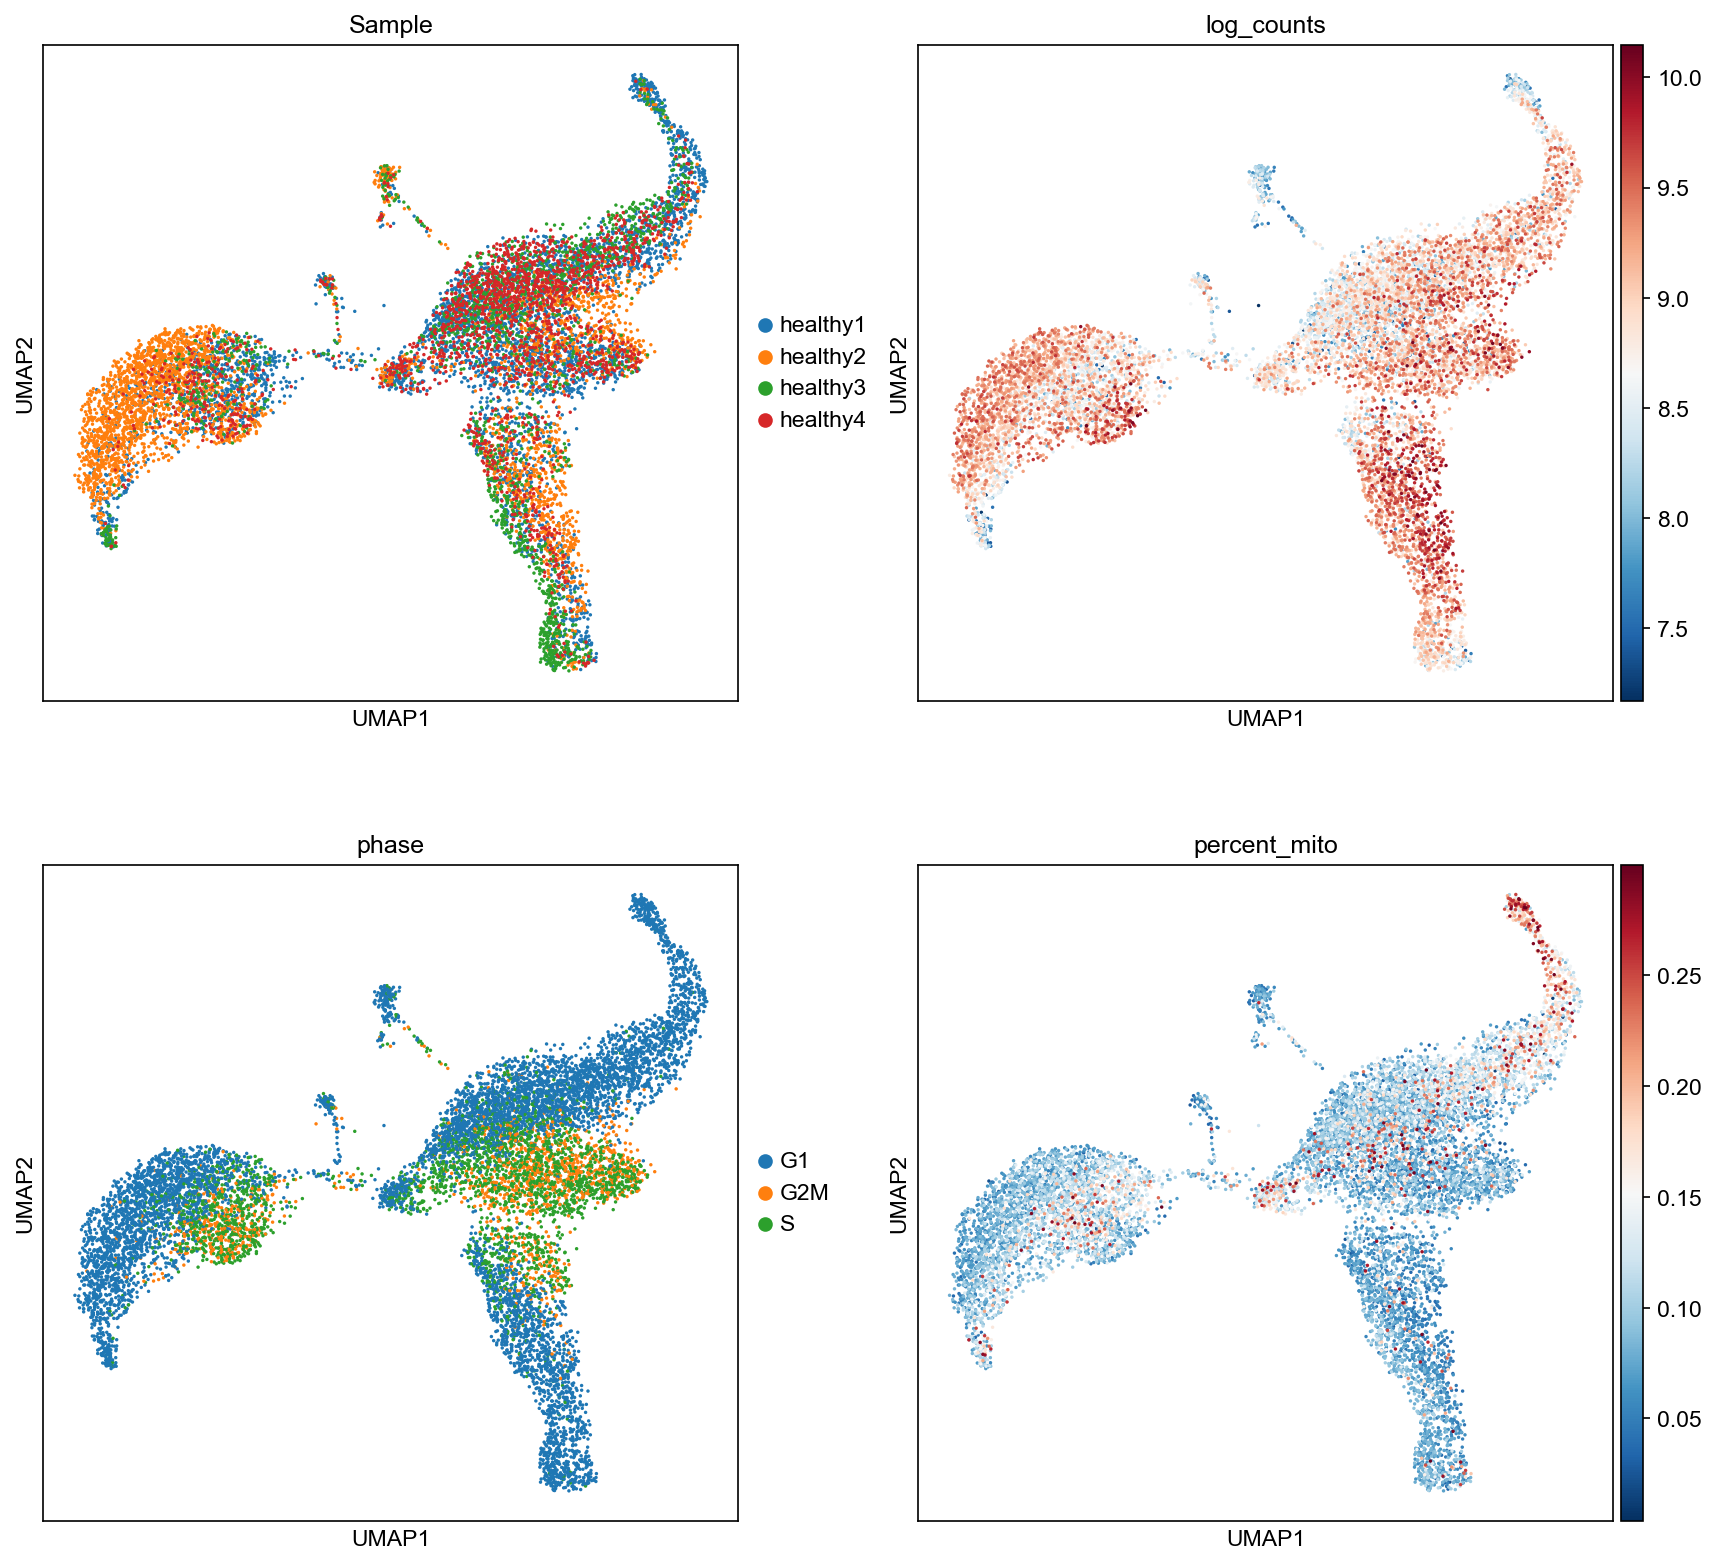

In [12]:
features = ['Sample', 'log_counts', 'phase', 'percent_mito']

sc.pl.umap(adata, color=features, ncols=2)

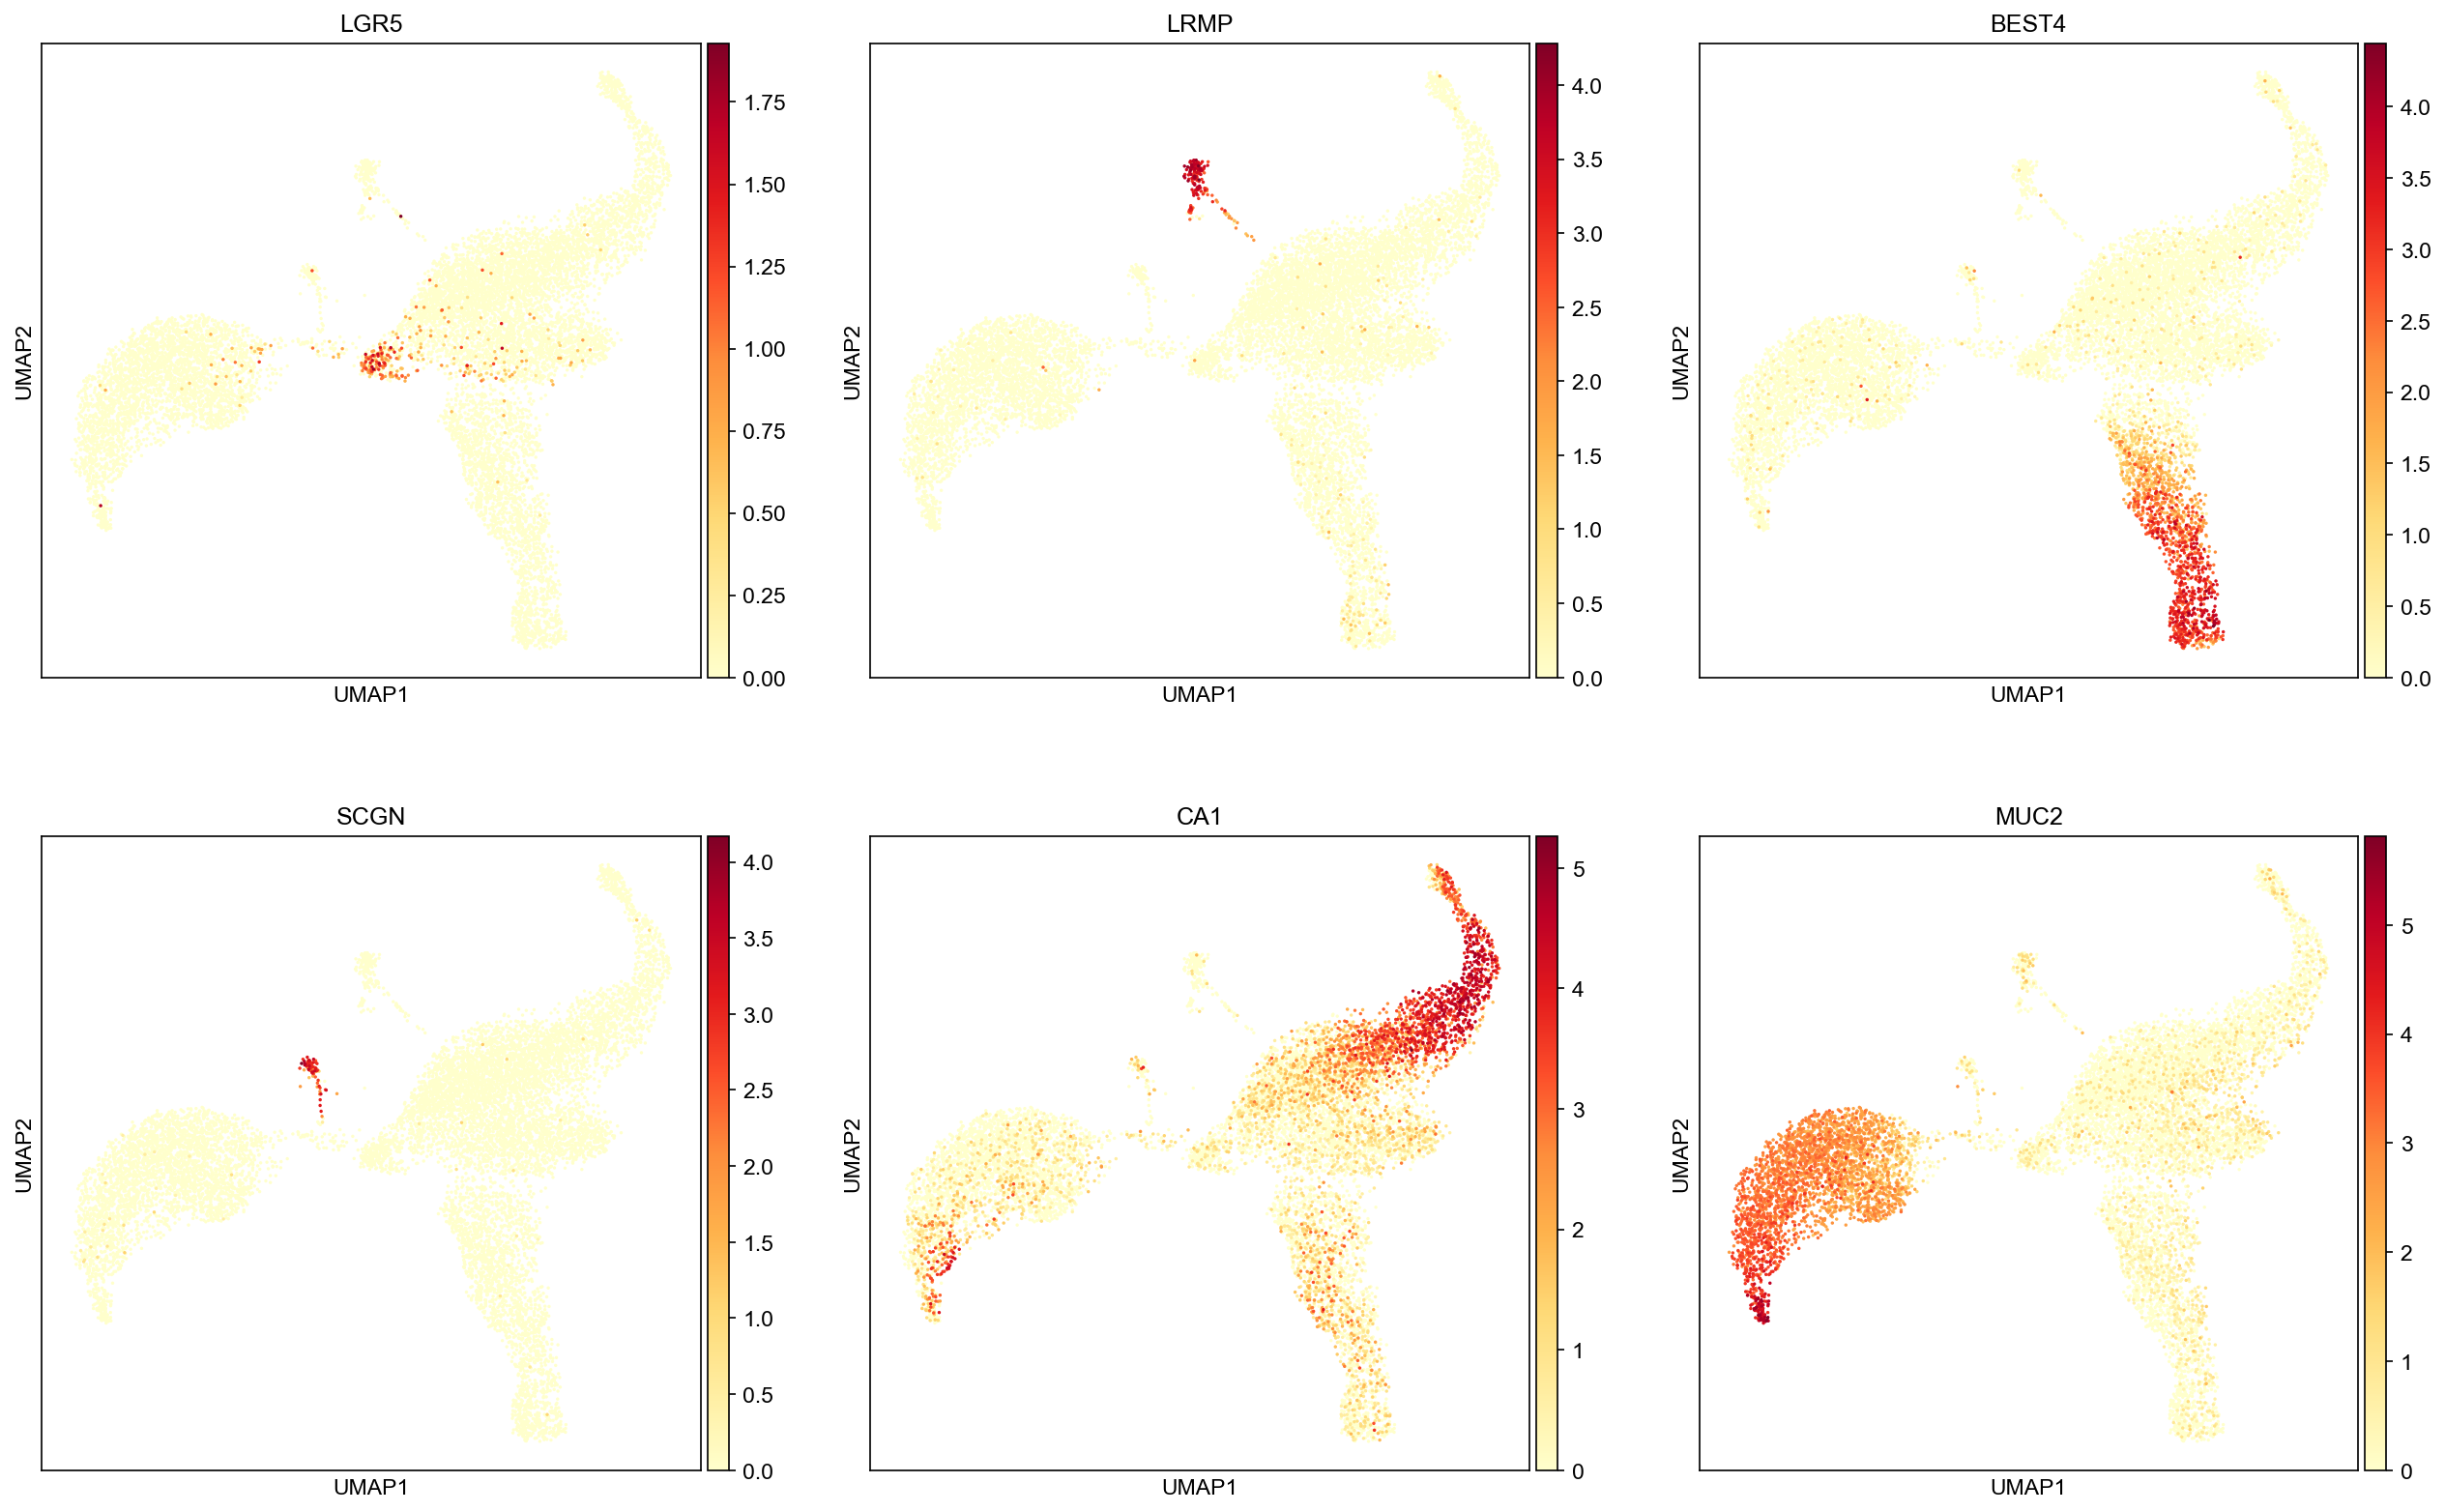

In [13]:
features = ['LGR5', 'LRMP', 'BEST4', 'SCGN', 'CA1', 'MUC2']

sc.pl.umap(adata, color=features, use_raw=True, ncols=3, cmap='YlOrRd')

#### 5. Save data for the next step 

In [14]:
adata.write("healthy_dr.h5ad")